In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../Codes/library/')

from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/antigen_presentation/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


In [2]:
def simulate_exact(alpha, sigma, lam, delta, x0, T=None, Theta=None, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        # birth clock (NHPP)
        r = rng.exponential(1.0)
        tau_b = (1.0/lam) * np.log(1.0 + (lam/(1e-1*alpha**sigma))*r*np.exp(-lam*t))

        # death clock
        if n > 0:
            tau_d = rng.exponential(1.0/(delta*n))
        else:
            tau_d = np.inf

        if tau_b < tau_d:
            t += tau_b
            n += 1
        else:
            t += tau_d
            n -= 1

        traj.append((t, n))

    return traj  # also return division time if Theta used

In [3]:
def simulate_tauleap(alpha, lam, delta, x0, T=None, Theta=None,
                     eps=0.05, eta=0.2, dt_max=np.inf, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        dt1 = (1.0/lam) * np.log(1.0 + eps)         # control exp-growth change
        dt2 = eta / delta                            # control death fraction
        dt  = min(dt1, dt2, dt_max)

        # don't step past the end time
        if T is not None:
            dt = min(dt, T - t)
            if dt <= 0: break

        # births: Poisson with integrated intensity
        m_b = (alpha/lam) * (np.exp(lam*(t+dt)) - np.exp(lam*t))
        B = rng.poisson(m_b)

        # deaths: Binomial (nonnegative guarantee)
        p = 1.0 - np.exp(-delta*dt)
        D = rng.binomial(n, p) if n > 0 else 0

        n = n + B - D
        t = t + dt
        traj.append((t, n))

    return traj

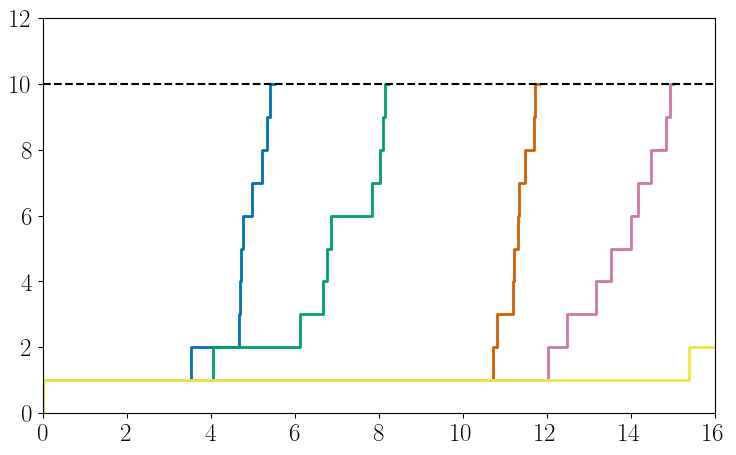

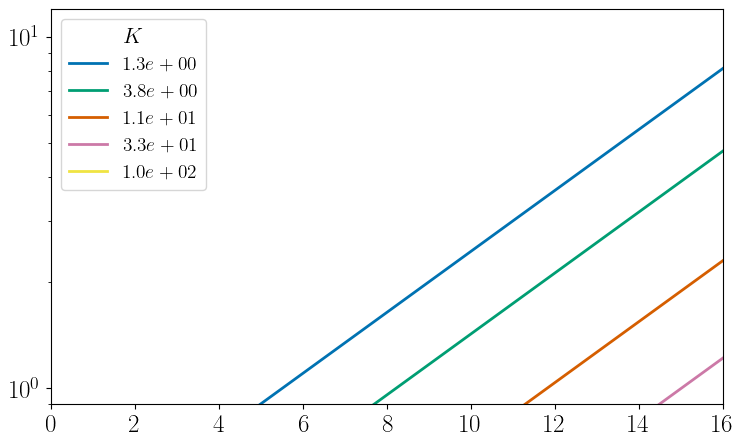

In [ ]:
plt.style.use("seaborn-v0_8-colorblind")
fig_pi, ax_pi = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
fig_cs, ax_cs = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
beta = 2.2
sigmas = [1.0, 3.0]
thetas = [10.0, 1.0]
data_simulation = defaultdict(list)
for theta in thetas:
    for sigma in sigmas:
        times = np.linspace(0, 20, 100)
        Ks = np.logspace(0.1, 2.0, 10)
        for i_ens in range(1):
            for K, omega in zip(Ks, Ks**beta):
                ts_act = []
                for n in range(int(omega)):
                    traj1 = simulate_exact(alpha=1/K, sigma = sigma, lam=1, delta=0.001, x0=0, T=20, Theta=theta)
                    ts_act.append(traj1[-1][0])
                    # traj2 = simulate_tauleap(alpha=alpha, lam=1, delta=0.01, x0=0, T=20, Theta=theta)
                data_simulation['beta'].append(beta)
                data_simulation['sigma'].append(sigma)
                data_simulation['theta'].append(theta)
                data_simulation['K'].append(K)
                data_simulation['N0'].append(omega)
                data_simulation['t_act_mean'].append(np.mean(ts_act))
                data_simulation['t_act_min'].append(np.min(ts_act))
                if i_ens == 0 and sigma == sigmas[-1] and theta == thetas[0]:
                    ax_pi.step(*zip(*traj1), lw = 2, label = r'$%.1e$'%K)
                    ax_cs.plot(times, np.exp(0.2*(times - traj1[-1][0])), lw = 2, label = r'$%.1e$'%K)

ax_pi.hlines(thetas[0], 0, 20, colors='k', linestyles='dashed')
data_simulation_df = pd.DataFrame(data_simulation)
result = (
    data_simulation_df.groupby(["sigma", "theta", "K", 'N0'])[["t_act_mean", "t_act_min"]]
    .mean()
    .reset_index()
)
# my_plot_layout(ax=ax_pi, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
# ax.set_yscale('log')
ax_pi.set_ylim(bottom=0, top = 1.2*thetas[0])
ax_pi.set_xlim(left=0, right=16)
ax_pi.tick_params(axis='both', which='major', labelsize=18)
# ax_pi.legend(loc = 2, fontsize = 14, title = r'$K$', title_fontsize = 16)
fig_pi.savefig(output_plot + 'trajectories.pdf')


# my_plot_layout(ax=ax_cs, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_cs.set_yscale('log')
ax_cs.set_ylim(bottom=0.9, top = 1.2*thetas[0])
ax_cs.set_xlim(left=0, right=16)
ax_cs.tick_params(axis='both', which='major', labelsize=18)
ax_cs.legend(loc = 2, fontsize = 14, title = r'$K$', title_fontsize = 16)
fig_cs.savefig(output_plot + 'clone-sizes.pdf')

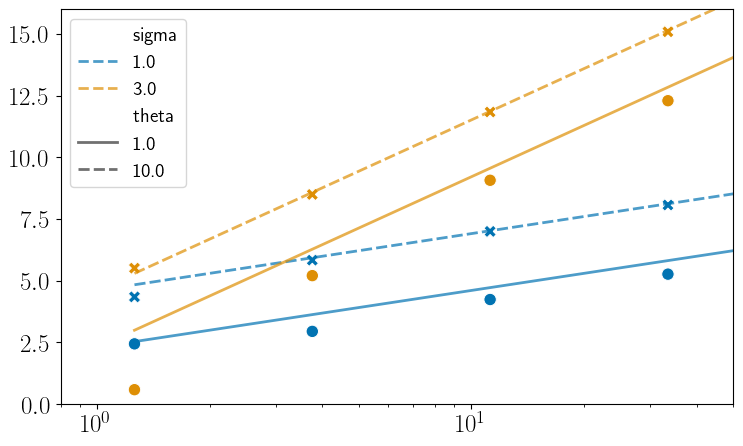

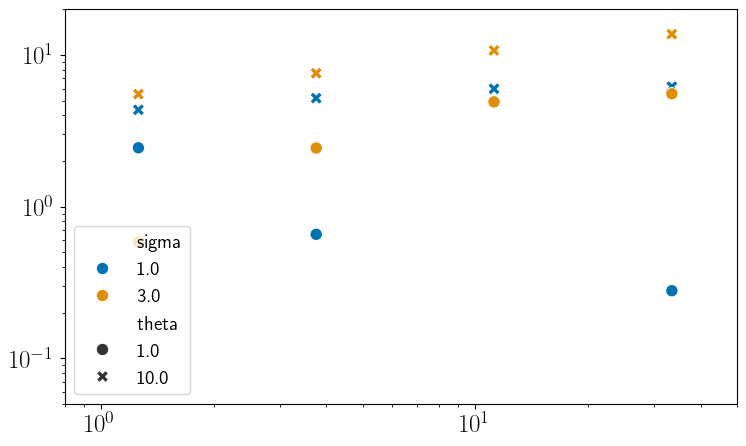

In [25]:
fig_mean, ax_mean = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
result['t_act_mean_theory'] = np.log(1/1e-1) + result['sigma']*np.log(result['K']) + np.log(result['theta']) 
sns.scatterplot(data = result, x = 'K', y = 't_act_mean', hue = 'sigma', style = 'theta', ax=ax_mean, legend=False, palette='colorblind', s=80)
sns.lineplot(data = result, x = 'K', y = 't_act_mean_theory', hue = 'sigma', style = 'theta', ax=ax_mean, legend=True, linestyle='--', palette='colorblind', lw = 2, alpha = 0.7)
# my_plot_layout(ax=ax_mean, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_mean.set_xscale('log')
# ax_mean.set_yscale('log')
ax_mean.tick_params(axis='both', which='major', labelsize=18)
ax_mean.set_ylim(bottom=0, top = 16)
ax_mean.set_xlim(left=0.8, right=50)
ax_mean.legend(loc = 2, fontsize = 14)
ax_mean.set(xlabel=None, ylabel=None)
fig_mean.savefig(output_plot + 'times_mean.pdf')

fig_min, ax_min = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
sns.scatterplot(data = result, x = 'K', y = 't_act_min', hue = 'sigma', style = 'theta', ax=ax_min, legend=True, palette='colorblind', s=80)
# sns.lineplot(data = result, x = 'K', y = 't_act_mean_theory', hue = 'sigma', style = 'theta', ax=ax_min, legend=True, linestyle='--')
# my_plot_layout(ax=ax_min, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax_min.set_xscale('log')
ax_min.set_yscale('log')
ax_min.tick_params(axis='both', which='major', labelsize=18)
ax_min.set_ylim(bottom=5e-2, top = 20)
ax_min.set_xlim(left=0.8, right=50)
ax_min.legend(loc = 3, fontsize = 14)
ax_min.set(xlabel=None, ylabel=None)
fig_min.savefig(output_plot + 'times_min.pdf')
